## Determining the phase shifts for scattering in a Lennard-Jones potential

In this notebook we'll study the scattering states in a Lennard-Jones potential:

$$
V(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]
$$ù

In [1]:
import numpy as np
import physipy as phys
import matplotlib.pyplot as plt
import scipy.constants as const

In [2]:
m_H  = 1.008 * const.u          # kg
m_Kr = 83.798 * const.u         # kg
mu   = m_H * m_Kr / (m_H + m_Kr)  # kg

hbar2_over_2mu = const.hbar**2 / (2 * mu)  # J·m²
hbar2_over_2mu_meV_A2 = hbar2_over_2mu * 6.242e21 * 1e20
print(f"ℏ²/2µ = {hbar2_over_2mu_meV_A2:.6f} meV·Å²")

ℏ²/2µ = 2.098599 meV·Å²


We start by setting arbitrarly the parameters $$\epsilon = 5.99 \text{ meV}$$ and $$\sigma = 2.00 Å$$

In [3]:
kwargs = {'hbar_squared_over_2_m' : 2.098599, 'sigma' : 2, 'epsilon' : 5.99}

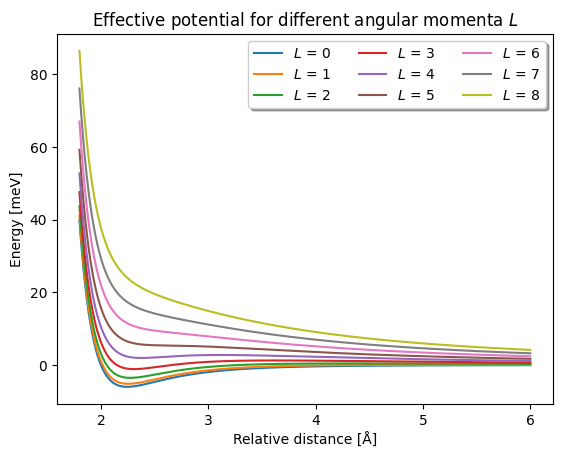

In [4]:
# print the effective potential for different angular momenta
r = np.linspace(0.9 * kwargs['sigma'], 6, 1000)
ls = np.arange(0, 9, 1)

plt.title('Effective potential for different angular momenta $L$')
for _l in ls:
    plt.plot(r, phys.effective_potential(r, _l, phys.lennard_jones, **kwargs), label = f'$L$ = {_l}')

plt.xlabel('Relative distance [Å]')
plt.ylabel('Energy [meV]')
plt.legend(ncols = 3, fancybox = True, shadow = True)
plt.show()


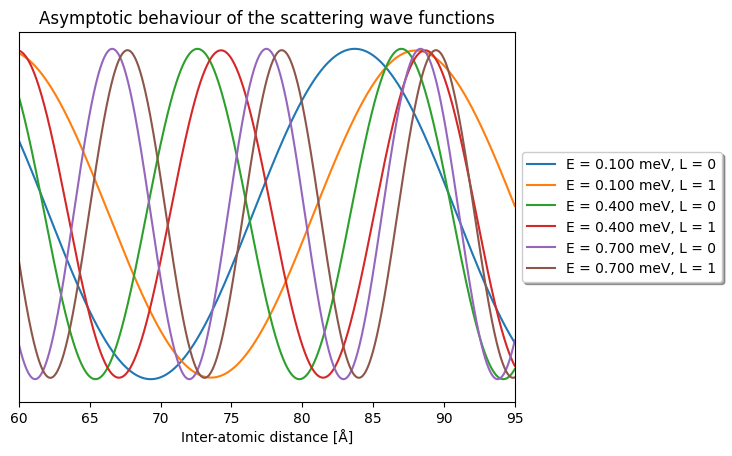

In [5]:
# print a few oscillations in the asymptotic regime
h = 1e-3
r_max = 100
E = np.arange(0.1, 1, .3)
ls = np.arange(0, 2, 1)

grid = phys.potentials.helper_grid_lj(h, r_max, sigma = kwargs['sigma'])
solver = phys.numerics.SolverOpts()

plt.title('Asymptotic behaviour of the scattering wave functions')
for _E in E:
    for _l in ls:
        coord, psi = phys.scattering.integrate_scattering_state(_E, _l, phys.potentials.lennard_jones, grid = grid, solver = solver, **kwargs)
        plt.plot(coord, psi/np.max(psi), label = f'E = {_E:.3f} meV, L = {_l}')

plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
plt.yticks(ticks = [])
plt.xlim([60, 95])
plt.xlabel('Inter-atomic distance [Å]')
plt.show()


Solve the Schrodinger equation for $l \in [0, 6]$ and $E \in [0.1, 3.5)$

In [6]:
ls = np.arange(0, 7, 1)
E = np.linspace(0.1, 3.5, 100)
hs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
solver = phys.numerics.SolverOpts()

In [8]:
i = 0
phases = np.zeros((len(hs), len(E), len(ls)))

for _h in hs:
    j = 0
    for _E in E:
        z = 0
        for _l in ls:
            points_needed = phys.n_points_needed(_E, kwargs['hbar_squared_over_2_m'], _h)
            r_min = phys.r_asym_min(_E, _l, phys.lennard_jones, kwargs['hbar_squared_over_2_m'], **kwargs)
            r_max = r_min + points_needed * _h
            grid = phys.potentials.helper_grid_lj(_h, r_max, sigma = kwargs['sigma'])
            print(f'For E = {_E:.3f} and l = {_l} h = {_h:.2e} r_min = {r_min:.3f} r_max = {r_max:.3f} and points_needed = {points_needed}')
            coord, psi = phys.integrate_scattering_state(_E, _l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = points_needed, **kwargs)
            # compute phases
            mean_phase, std_phase = phys.compute_phase_shift(psi, coord, _E, _l, **kwargs)
            print(f'For E = {_E:.3f} and l = {_l} h = {_h:.2e} ps = {mean_phase:.2e} with std dev = {std_phase:.2e}')
            phases[i, j, z] = mean_phase
            z += 1
        j += 1
    i += 1
    

For E = 0.100 and l = 0 h = 1.00e-01 r_min = 20.000 r_max = 106.400 and points_needed = 864
For E=0.100 and l=0 r1=26.10, r2=33.30 → δ = -0.997215 rad
For E=0.100 and l=0 r1=54.90, r2=62.10 → δ = -0.993782 rad
For E = 0.100 and l = 0 h = 1.00e-01 ps = -9.95e-01 with std dev = 1.72e-03
For E = 0.100 and l = 1 h = 1.00e-01 r_min = 20.000 r_max = 106.400 and points_needed = 864
For E=0.100 and l=1 r1=30.00, r2=37.20 → δ = -0.427987 rad
For E=0.100 and l=1 r1=59.10, r2=66.30 → δ = -0.416881 rad
For E=0.100 and l=1 r1=88.00, r2=95.20 → δ = -0.415244 rad
For E = 0.100 and l = 1 h = 1.00e-01 ps = -4.20e-01 with std dev = 5.66e-03
For E = 0.100 and l = 2 h = 1.00e-01 r_min = 22.442 r_max = 108.842 and points_needed = 864
For E=0.100 and l=2 r1=49.00, r2=56.30 → δ = -3.126710 rad
For E=0.100 and l=2 r1=78.30, r2=85.60 → δ = -3.119342 rad
For E = 0.100 and l = 2 h = 1.00e-01 ps = 1.86e-02 with std dev = 3.68e-03
For E = 0.100 and l = 3 h = 1.00e-01 r_min = 31.738 r_max = 118.138 and points_neede

KeyboardInterrupt: 

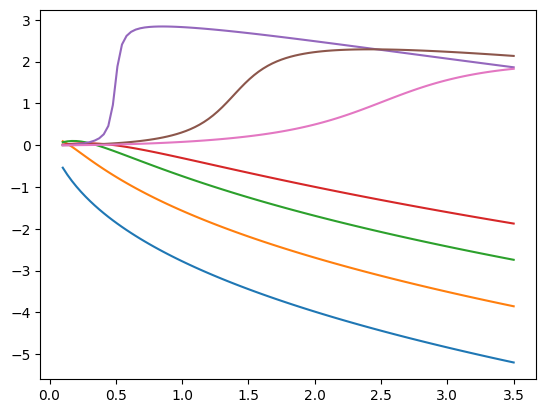

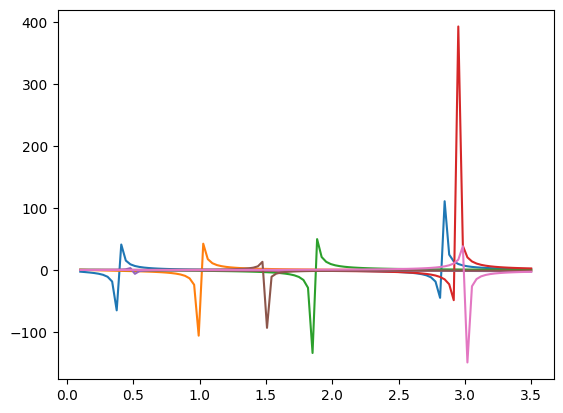

In [27]:
phases_unwrap = np.unwrap(phases, period=np.pi, axis = -1)

plt.plot(E, phases_unwrap.T)
plt.show()
plt.plot(E, (np.tan(phases_unwrap) / phys.wave_vector(E, **kwargs)).T)

In [28]:
i = 0
for _l in ls:
    cross_section += 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * _l + 1) * np.pow(np.sin(phases_unwrap[i, :]), 2) / E
    i += 1

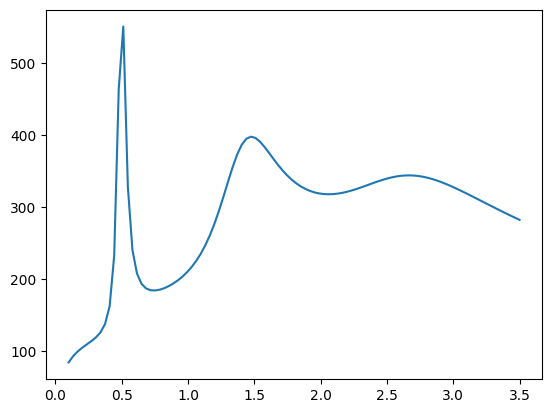

In [29]:
plt.plot(E, cross_section)

In [ ]:
from scipy import signal
def single_energy_error(sigma_variable,l,E_exp,delta_E,h):
    kwargs = {'hbar_squared_over_2_m' : 2.098599, 'sigma' : sigma_variable, 'epsilon' : 5.99}
    E = np.arange(E_exp-delta_E, E_exp+delta_E, 0.01)
    solver = phys.numerics.SolverOpts()
    phases = np.zeros(len(E))
    i=0
    for _E in E:
        points_needed = phys.n_points_needed(_E, kwargs['hbar_squared_over_2_m'], h)
        r_min = phys.r_asym_min(_E, l, phys.lennard_jones, kwargs['hbar_squared_over_2_m'], **kwargs)
        r_max = r_min + points_needed * h
        grid = phys.potentials.helper_grid_lj(h, r_max, sigma = kwargs['sigma'])
        #print(f'For E = {_E:.3f} and l = {l} h = {h:.2e} r_min = {r_min:.3f} r_max = {r_max:.3f} and points_needed = {points_needed}')
        coord, psi = phys.integrate_scattering_state(_E, l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = points_needed, **kwargs)
        # compute phases
        mean_phase, std_phase = phys.compute_phase_shift(psi, coord, _E, l, **kwargs)
        #print(f'For E = {_E:.3f} and l = {l} h = {h:.2e} ps = {mean_phase:.2e} with std dev = {std_phase:.2e}')
        phases[i] = mean_phase
        i+=1
    phases_unwrap = np.unwrap(phases, period=np.pi, axis = -1)
    cross_section=np.zeros(len(E))
    for i in range(len(E)):
        cross_section[i]= 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * l + 1) * np.pow(np.sin(phases_unwrap[i]), 2) / E[i]
    plt.plot(E,cross_section)

    
    peak_index=signal.find_peaks(cross_section)
    E_peak=E[peak_index[0]]
    error=(E_peak-E_exp)**2
    print(E_peak)
    return(error)

print(single_energy_error(2,5,1.59,0.3,0.01))
from scipy import optimize
#sigma_fit=optimize.minimize(single_energy_error,2,args=(4, 0.5, 0.01))

        
        